<IMG SRC="https://ucalgary.ca/themes/ucalgary/ucws_theme/images/UCalgary.svg" WIDTH=250 ALIGN="right"></IMG>
## Reading $ \dot{V}0_2$ data a practicle example...   
    
#### Developed by R. John Holash, University of Calgary  

### We will start this session by importing a dataset into the python environment   
    
You will notice that this dataset is far more complex than the dataset you worked with yesterday.
Just as a *hint* if you click on one of the database files to the right in the "Datasets" box, you can quickly view the dataset and Kaggle will present you with a path that you can copy into your code to the dataset.

In the example below we will use the two letters df to be the variables that define our dataframe. A dataframe is essentially a copy of the data from the file that we read into python.  We do this so we are always working with a copy of the data and not the original data (very important). If we make any mistakes in our code while we are cleaning or "wrangling" the data that is fine as we can always just go load a fresh copy and not repeat the mistake (hopefully). 😊

The code is doing these functions on each line:  

    - Read the contents of the file into the dataframe called df. We use `pd.read_csv` but could also use `pd.read_excel`. Type `pd.read` then hit the tab key when your cursor is at the end of `read` and you will see all the file types you can read using pandas (pd).
    
    - Show me information on the datafram I just created, we use this instead of  `df.shape()` as we have a tuple (multiple values) in the `df`   
    
    - Print out the first few rows of the dataframe I just collected (default is 5) change `df.head()` to `df.head(10)` and see what happens. 

In [102]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/demo-knes381/subject_1321.xlsx
/kaggle/input/demo-knes381/subject_1432.xlsx
/kaggle/input/demo-knes381/subject_1321.csv
/kaggle/input/demo-knes381/subject_1232.csv
/kaggle/input/demo-knes381/VO2_CSV.csv
/kaggle/input/demo-knes381/subject_1232.xlsx
/kaggle/input/demo-knes381/subject_1432.csv
/kaggle/input/demo-knes381/subject_1523.csv
/kaggle/input/demo-knes381/VO2_excel.xlsx
/kaggle/input/demo-knes381/subject_1523.xlsx


In [103]:
# df_excel = pd.read_excel("/kaggle/input/demo-knes381/VO2_excel.xlsx") will read the excel version of this file

df = pd.read_csv('../input/demo-knes381/VO2_CSV.csv')
df.info()
df.head(5)
# this function will throw errors when if finds values that are blank NaN (not a number)
# you can ignore this we will fix it momentarily...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TIME    57 non-null     object 
 1   VO2     57 non-null     object 
 2   VO2/kg  57 non-null     object 
 3   METS    55 non-null     float64
 4   VCO2    57 non-null     object 
 5   VE      57 non-null     object 
 6   RER     55 non-null     float64
 7   RR      56 non-null     object 
 8   Vt      57 non-null     object 
 9   FEO2    56 non-null     object 
 10  FECO2   56 non-null     object 
 11  HR      56 non-null     object 
 12  VE/     57 non-null     object 
 13  VE/.1   57 non-null     object 
 14  PetCO2  56 non-null     object 
 15  Power   56 non-null     object 
dtypes: float64(2), object(14)
memory usage: 7.4+ KB


,TIME,VO2,VO2/kg,METS,VCO2,VE,RER,RR,Vt,FEO2,FECO2,HR,VE/,VE/.1,PetCO2,Power
0,NaN,STPD,STPD,NaN,STPD,BTPS,NaN,NaN,BTPS,NaN,NaN,NaN,VO2,VCO2,NaN,NaN
1,min,L/min,ml/kg/m,NaN,L/min,L/min,NaN,BPM,L,%,%,bpm,BT/ST,BT/ST,mmHg,Watts
2,----------,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.517166674,0.247651309,4.552413464,1.300690,0.184219986,19.60388184,0.743868,17.4025135,1.126497149,19.24795151,1.362279773,82,79.15921021,106.4156113,10.53666782,50
4,1.0521667,0.687631011,12.64027596,3.611507,0.524605274,19.48801422,0.762917,22.42990494,0.868840694,16.21204948,3.827807426,84,28.34080124,37.14795685,25.49147987,50


## Headers and values
You might have noticed that when we import these values, pandas auto-majically recognizes that our columns have headers and uses these.  If you look closely though there are some errors when it does this (VE/.1) although it is generally ok.  

We can do a little better maybe... if we look at the data set we can see in the second row that the units for the headers are listed there.  At this stage we can programatically change this so when we create a header value it includes both the name and the units in a bracket right afterward.  But to do this we will need to stop pandas from automatically reading in the header.

Please see the comments in the code below for more of an explination for what it is doing 🤗

In [104]:
# Step 1: read in the dataframe and do not allow pandas to find the header.
# Please note that I am creating a new dataframe here df2 so we can compare
# df and df2 potentially in the future...

df2 = pd.read_csv('../input/demo-knes381/VO2_CSV.csv', header=None)
# Assuming the first row is the header and the third row contains units. please note that in the raw file if the header is the fist row it will be zero, 
# and the third row will be 2 as we start counting at zero instead of 1.

# Step 2: Set the header.

header = df2.iloc[0]
units = df2.iloc[2]

# Step 3: Combine header and units, replace NaN with blank.
new_header = [f"{h} ({u})" if not pd.isna(u) else f"{h}" for h, u in zip(header, units)]
# Reading from the back... zip (hader, units) pairs each element from the header with a unit
# If 'u' is valid it creates a string value formatted as header (unit)
# using f-string f"{h} ({u})", if u is NaN (not a number) it simply used the header h as the string f"{h}"
# the list of these formatings is then written into new_header

# Step 4: Reassign column names and drop extra rows.
df2.columns = new_header
df2 = df2.drop(index=[0, 1, 2, 3])

# Optionally, reset index if you want a clean, zero-based index.
df2.reset_index(drop=True, inplace=True)
df2.head()

,TIME (min),VO2 (L/min),VO2/kg (ml/kg/m),METS,VCO2 (L/min),VE (L/min),RER,RR (BPM),Vt (L),FEO2 (%),FECO2 (%),HR (bpm),VE/ (BT/ST),VE/ (BT/ST),PetCO2 (mmHg),Power (Watts)
0,0.517166674,0.247651309,4.552413464,1.300689578,0.184219986,19.60388184,0.743868411,17.4025135,1.126497149,19.24795151,1.362279773,82,79.15921021,106.4156113,10.53666782,50
1,1.0521667,0.687631011,12.64027596,3.611507416,0.524605274,19.48801422,0.762916863,22.42990494,0.868840694,16.21204948,3.827807426,84,28.34080124,37.14795685,25.49147987,50
2,1.517833352,0.900826395,16.55930901,4.731231213,0.674840033,23.45595932,0.749134421,19.32712936,1.213628769,15.81043339,4.088318348,87,26.03826904,34.75780487,27.31636238,50
3,2.040499926,0.907712698,16.68589401,4.767398357,0.675091565,23.95195961,0.74372822,21.04591942,1.138080955,15.88415718,4.005978107,99,26.38715935,35.4795723,26.74253273,50
4,2.548999786,1.018968821,18.73104477,5.351727009,0.757926047,25.988657,0.743816733,19.66568375,1.32152319,15.70950413,4.14366293,98.5,25.50485992,34.28917313,27.54349518,50


In [105]:
df2.tail() # you can see the end of the table too by using the tail command instead of the head command.

,TIME (min),VO2 (L/min),VO2/kg (ml/kg/m),METS,VCO2 (L/min),VE (L/min),RER,RR (BPM),Vt (L),FEO2 (%),FECO2 (%),HR (bpm),VE/ (BT/ST),VE/ (BT/ST),PetCO2 (mmHg),Power (Watts)
50,25.50416183,2.552968264,46.92956161,13.40844631,2.76861763,96.85891724,1.084470034,53.02515793,1.826659679,17.15613937,4.061412811,166,37.93972778,34.98457718,26.97459984,250
51,26.00832558,2.599028111,47.77624893,13.65035725,2.842338324,99.30608368,1.09361589,55.53718948,1.7881006,17.17567825,4.066742897,167,38.20893097,34.93816376,26.99367523,250
52,26.51082611,2.545781851,46.79745865,13.37070274,2.79125309,97.44702911,1.096422672,55.72138596,1.748826385,17.18027687,4.069806099,168,38.27783966,34.9115715,27.04037666,250
53,27.0059948,2.566305161,47.17472458,13.47849274,2.846503258,102.3163757,1.109183431,60.58565521,1.688788772,17.32051849,3.953977108,168,39.86913681,35.94458389,26.29595947,250
54,27.38599777,2.53116107,46.52869415,13.29391289,2.81175518,97.97476196,1.110855937,57.89474106,1.69229126,17.21091461,4.077520847,169,38.70743942,34.84469986,27.06917953,250


In [106]:
df2.info() # when we look at the info this is fairly easy to read...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   TIME (min)        55 non-null     object
 1   VO2 (L/min)       55 non-null     object
 2   VO2/kg (ml/kg/m)  55 non-null     object
 3   METS              55 non-null     object
 4   VCO2 (L/min)      55 non-null     object
 5   VE (L/min)        55 non-null     object
 6   RER               55 non-null     object
 7   RR (BPM)          55 non-null     object
 8   Vt (L)            55 non-null     object
 9   FEO2 (%)          55 non-null     object
 10  FECO2 (%)         55 non-null     object
 11  HR (bpm)          55 non-null     object
 12  VE/ (BT/ST)       55 non-null     object
 13  VE/ (BT/ST)       55 non-null     object
 14  PetCO2 (mmHg)     55 non-null     object
 15  Power (Watts)     55 non-null     object
dtypes: object(16)
memory usage: 7.0+ KB


### Try this out yourself!
Use the code example above to open the `subject_1232.csv file.`  Look at the head of the file, tail of the file, and the info. Anything different?  

As a hint import the file into a "new" dataframe call it df3, or df_test, or whatever you like (with df3 you type less)

In [107]:
# This is your tryout cell$

### Note
I created a second dataframe here to load the data into called `df2` so I don't overwrite my intial dataframe  
One problem with this method is now my headers have spaces! and you know I don't like spaces in names.  This can be an issue when we are calling these values later and I would always need to remember to enclose the value in quotes either single or double so that python does not read two things here. Try to limit in as many ways as possible the oppertunities for you to make mistakes in your code. The best practice is to use simple header names and very simple variable names like df instead of dataframe. Either works but you need to remember you will be typing them often... That said make sure they are meaningful to you, it is very painful to edit code later with non-informative variable names like v1, v2, v3 as you will need to keep in your mind that v1 is jump_height and v2 is mass... 

In [108]:

print(df['TIME'].describe())  # I put the df[`TIME`]... in a print statment so that we see the results of both commands, it is not normally necessary
# otherwise it would overwrite the first df[`TIME`] with the results of the second call below so fast you wont see it.

df2['TIME (min)'].describe()

# that said if you type df2[''] when you cursor is between the two quote hit tab and all the names for the columns will appear as option
# also note that in our first dataframe as we have 57 values the first value in the column `top`is "min"  whereas in df2 the `top` value is .0517...
# in both cases the descriptive statistics are poor as pythons sees this value as an object and not a float or intiger

count      57
unique     57
top       min
freq        1
Name: TIME, dtype: object


count              55
unique             55
top       0.517166674
freq                1
Name: TIME (min), dtype: object

### Reading excel files  
You can read in an excel file the same way you just change the syntax of the `pd.read_` statement. If you open the datasets in the browser below take note of the size of the data sets... the same data in excel is 3 x the size as a csv file.

In [109]:
    df = pd.read_csv('/kaggle/input/demo-knes381/subject_1321.csv') 
# you can read excel files and they will work the same way
# nothing will happen here except the number below the run arrow will increment [7]
# as we have not asked python to do anything after reading in the file to the dataframe
# we could add a print statment below it that said something like "df created" if we wanted.
# this will throw errors again as there are NaN values being read.

In [110]:
df.head()


,TIME,VO2,VO2/kg,METS,VCO2,VE,RER,RR,Vt,FEO2,FECO2,HR,VE/,VE/.1,PetCO2,Power,Lactate
0,NaN,STPD,STPD,NaN,STPD,BTPS,NaN,NaN,BTPS,NaN,NaN,NaN,VO2,VCO2,NaN,NaN,NaN
1,min,L/min,ml/kg/m,NaN,L/min,L/min,NaN,BPM,L,%,%,bpm,BT/ST,BT/ST,mmHg,W,mmol/L
2,----------,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.5485,0.286087,4.498218,1.285205,0.207759,10.016462,0.726212,16.408386,0.610448,17.150507,2.951995,74,35.01199,48.211826,19.651297,NaN,NaN
4,1.0485,0.323012,5.078805,1.451087,0.232768,11.156643,0.720616,18,0.619814,17.10355,2.969106,76,34.539406,47.930397,19.818874,NaN,NaN


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TIME     56 non-null     object 
 1   VO2      56 non-null     object 
 2   VO2/kg   56 non-null     object 
 3   METS     54 non-null     float64
 4   VCO2     56 non-null     object 
 5   VE       56 non-null     object 
 6   RER      54 non-null     float64
 7   RR       55 non-null     object 
 8   Vt       56 non-null     object 
 9   FEO2     55 non-null     object 
 10  FECO2    55 non-null     object 
 11  HR       55 non-null     object 
 12  VE/      56 non-null     object 
 13  VE/.1    56 non-null     object 
 14  PetCO2   55 non-null     object 
 15  Power    52 non-null     object 
 16  Lactate  9 non-null      object 
dtypes: float64(2), object(15)
memory usage: 7.7+ KB


### Dtype
As mentioned before the `Dtype` or datatype can limit what you do with the data, in this case i will run `the describe` command on RER which is a floadt64 Dtype

In [112]:
#df['RER'].describe()

df['RER'].describe()

# Now we get a complete output of the descriptive statistics for this column of data

count    54.000000
mean      0.840745
std       0.091360
min       0.681330
25%       0.769196
50%       0.839282
75%       0.907361
max       0.998624
Name: RER, dtype: float64

### Limit the number of rows in the header
If we do our input like before but now cut out the rows with no true data in them which are rows 1,2, and 3.  You will see pandas recognises that this is all numeric data and converts the data type for us to a float or int64.

In [113]:
# Please note we are redefining the dataframe df here all previous edits and changes will be lost when we run this command.
# As we import the data we tell the program that the header is found in row zero and to skip the next three rows

df = pd.read_csv('../input/demo-knes381/VO2_CSV.csv', header=[0], skiprows=[1,2,3])
# again we won't see anything happen here when this runs but the value should increment [17]...

In [114]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TIME    55 non-null     float64
 1   VO2     55 non-null     float64
 2   VO2/kg  55 non-null     float64
 3   METS    55 non-null     float64
 4   VCO2    55 non-null     float64
 5   VE      55 non-null     float64
 6   RER     55 non-null     float64
 7   RR      55 non-null     float64
 8   Vt      55 non-null     float64
 9   FEO2    55 non-null     float64
 10  FECO2   55 non-null     float64
 11  HR      55 non-null     float64
 12  VE/     55 non-null     float64
 13  VE/.1   55 non-null     float64
 14  PetCO2  55 non-null     float64
 15  Power   55 non-null     int64  
dtypes: float64(15), int64(1)
memory usage: 7.0 KB


In [115]:
round(df['TIME'].std(), 3)
 # this will print the standard deviation of the "TIME" column to 3 decimal places

7.999

### Give it a try with your subject file  
Re-import the file this time drop the first three rows (after row 0) ;-)

In [116]:
# this is your tryout cell

### Renaming header values  
We can (and should) rename headers so that they are understandable to us in the future

In [117]:
# the convention for this is df.rename(columns={'old_name1': 'new_name1', 'old_name2': 'new_name2', 'old_name3': 'new_name3'})
df = df.rename(columns={'VE/': 'VE/VO2', 'VE/.1': 'VE/VCO2'})
# if we wanted to we could add the units as we did before here df.rename(columns={'old_name' : 'new_name(unit)'})


In [118]:
df.head()

,TIME,VO2,VO2/kg,METS,VCO2,VE,RER,RR,Vt,FEO2,FECO2,HR,VE/VO2,VE/VCO2,PetCO2,Power
0,0.517167,0.247651,4.552413,1.300690,0.184220,19.603882,0.743868,17.402514,1.126497,19.247952,1.362280,82.0,79.159210,106.415611,10.536668,50
1,1.052167,0.687631,12.640276,3.611507,0.524605,19.488014,0.762917,22.429905,0.868841,16.212049,3.827807,84.0,28.340801,37.147957,25.491480,50
2,1.517833,0.900826,16.559309,4.731231,0.674840,23.455959,0.749134,19.327129,1.213629,15.810433,4.088318,87.0,26.038269,34.757805,27.316362,50
3,2.040500,0.907713,16.685894,4.767398,0.675092,23.951960,0.743728,21.045919,1.138081,15.884157,4.005978,99.0,26.387159,35.479572,26.742533,50
4,2.549000,1.018969,18.731045,5.351727,0.757926,25.988657,0.743817,19.665684,1.321523,15.709504,4.143663,98.5,25.504860,34.289173,27.543495,50


### Try this out with your dataframe rename some of the columns..


In [119]:
# this is your tryout cell

### *Note* 
#### Now you can type df['hit-tab'] and a list of names shows up...  
You don't type "hit-tab" you just perform the verb

In [120]:
df['HR'].std() # .std means standard deviation of the HR column

25.18620888194803

### Give it try!

In [121]:
# Type df[''] and hit tab with your cursor between the two '' marks.

### To round the value, you need to round the output of the dataframe df['HR'] to 2 digits like this

In [122]:
 # .std means standard deviation of the HR column
round(df['HR'].std(), 2)

25.19

### All the previous work was to look at the data we imported and to see it in the dataframe
it is not a requirement of creating a plot, or importing data! So lets start off and put the minimum code to create a plot in...

In [123]:
# df = pd.read_csv('../input/demo-knes381/VO2_CSV.csv', header=[0], skiprows=[1,2,3])
# we can assume you have done this.. The point of this part was to show you you can do a plot with two commands...

In [124]:
import matplotlib.pyplot as plt

#### You can create a plot based on column names

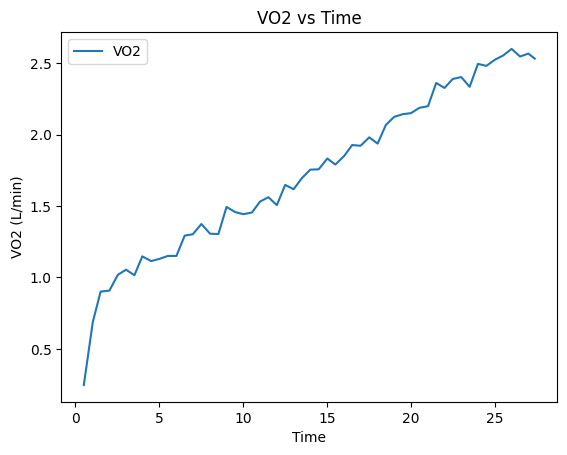

In [125]:
df.plot('TIME', 'VO2')

plt.xlabel('Time')  
plt.ylabel('VO2 (L/min)')
plt.title('VO2 vs Time')

plt.show()

### Try this with the dataframe you imported  
What changes?

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_55/567488425.py:4: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(x, y, c= 'r', label = '$\dot VO_2$') # bracketing this in $ puts this into mathmode
/tmp/ipykernel_55/567488425.py:8: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(x, y1, c='b', label='$\dot VC0_2$')


Text(0, 0.5, 'L/min')

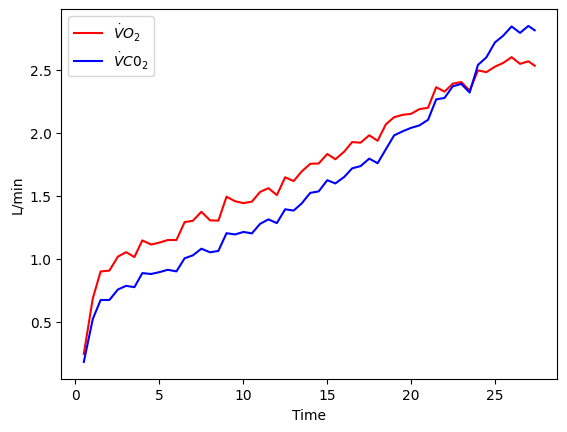

In [126]:
x = df['TIME']
y = df['VO2']
y1 = df['VCO2'] # second y plot
plt.plot(x, y, c= 'r', label = '$\dot VO_2$') # bracketing this in $ puts this into mathmode
# where you can create special characters and names _2 makes a subscript 2, 
# ^2 would make a superscript 2,
# \dot V  puts a dot over the V... this is defined in latex type.
plt.plot(x, y1, c='b', label='$\dot VC0_2$')
plt.legend()
plt.xlabel('Time')  # This creates a x axis label for the plot
plt.ylabel('L/min')  # This defines the y axix label for the plot


#### We can save this plot at any time by typing this command
As noted above it will create a better image if we save the image before we display it... The reason for this is that there is formating on the image that is done when displayed, that can alter the saved image.

In [127]:
df.columns

Index(['TIME', 'VO2', 'VO2/kg', 'METS', 'VCO2', 'VE', 'RER', 'RR', 'Vt',
       'FEO2', 'FECO2', 'HR', 'VE/VO2', 'VE/VCO2', 'PetCO2', 'Power'],
      dtype='object')

In [128]:
plt.savefig("V02-VC02.png", dpi=300, bbox_inches = "tight")

<Figure size 640x480 with 0 Axes>

### We can invoke the matplotlib axes feature to add more data to our plot like this:

Please pay special attention to the last few lines of code in this example, it is important to save the image before you display it.  This seems counter intuitive but is important, you can comment out the save line if you have never seen the graph before and want to see if it is working out before you save a hard copy.

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_55/255722602.py:12: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(x, y, c='r', label='$\dot{V}O_2$') # This is LaTeX math code that I am using for the legends
/tmp/ipykernel_55/255722602.py:13: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(x, y1, c='b', label='$\dot{V}CO_2$')# Matplotlib has full support for LaTeX
/tmp/ipykernel_55/255722602.py:21: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title('$\dot{V}O_2$ Plot')


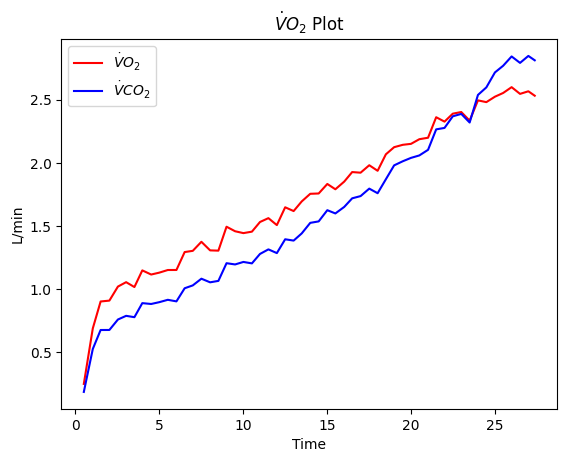

In [129]:
# import matplotlib.pyplot as plt we have already done this

# Assuming df['TIME'], df['VO2'], and df['VCO2'] are defined
x = df['TIME']
y = df['VO2']
y1 = df['VCO2']

# Create a figure and one subplot (ax) This allows us great flexibility with setting features
fig, ax = plt.subplots()

# Plot data on the ax object
ax.plot(x, y, c='r', label='$\dot{V}O_2$') # This is LaTeX math code that I am using for the legends
ax.plot(x, y1, c='b', label='$\dot{V}CO_2$')# Matplotlib has full support for LaTeX

# Add legend
ax.legend()

# Set x-axis and y-axis labels
ax.set_xlabel('Time')  # Set the x-axis label
ax.set_ylabel('L/min')  # Set the y-axis label, replace 'Value' with a descriptive term for your data
ax.set_title('$\dot{V}O_2$ Plot')
# If we want to save the figure we call this function before we "show" it as this might change the figure

# plt.savefig('VO2_plot.png', format='png', dpi=300, bbox_inches='tight')
# we need to call the show function to render this to the screen we can avoid this step if we are processing many files at once.
plt.show() # this gets rid of the information on the top right of the plot and is a little higher quality

### Give this a try, create a plot with the dataframe you have. 
Can you add any of the features to the graph, colours, marker size that you did last class to spice it up?

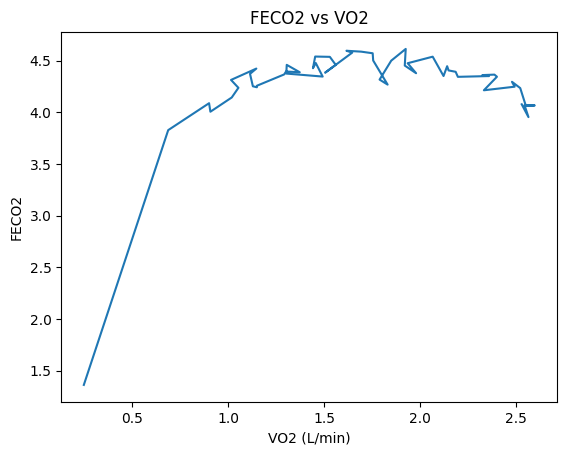

In [130]:
plt.figure()

plt.plot(df['VO2'], df['FECO2'])

plt.xlabel('VO2 (L/min)')
plt.ylabel('FECO2')
plt.title('FECO2 vs VO2')

plt.show()

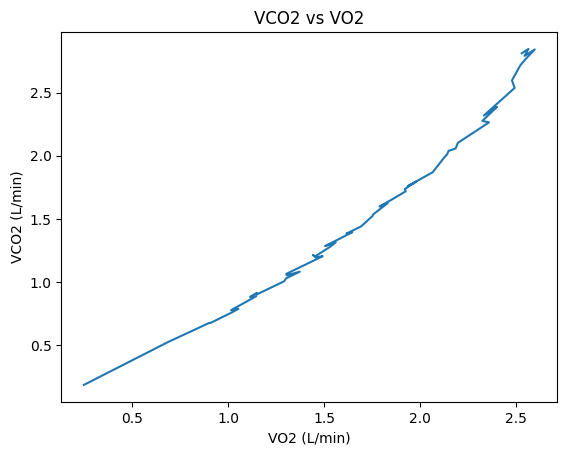

In [131]:
plt.figure()

plt.plot(df['VO2'], df['VCO2'])

plt.xlabel('VO2 (L/min)')
plt.ylabel('VCO2 (L/min)')
plt.title('VCO2 vs VO2')

plt.show()

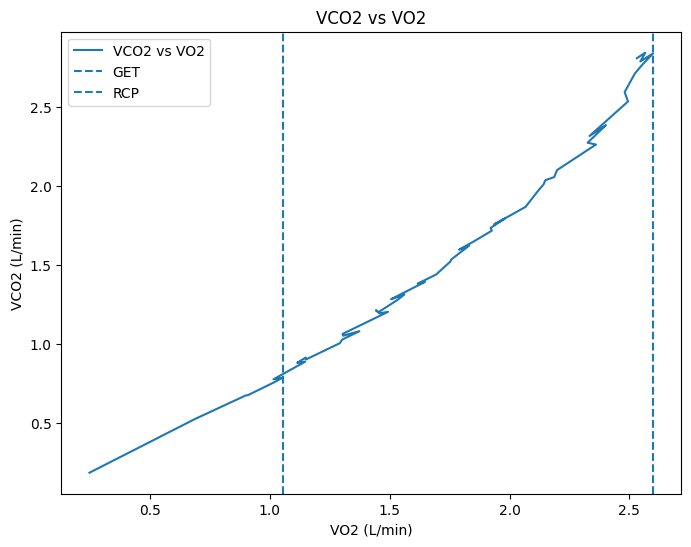

In [132]:

plt.figure(figsize=(8,6))

plt.plot(df['VO2'], df['VCO2'], label='VCO2 vs VO2')
plt.axvline(get_vo2, linestyle='--', label='GET')
plt.axvline(rcp_vo2, linestyle='--', label='RCP')

plt.xlabel('VO2 (L/min)')
plt.ylabel('VCO2 (L/min)')
plt.title('VCO2 vs VO2')
plt.legend()
plt.show()

In [133]:


# Calculate slope (change in VCO2 relative to VO2)
slope = np.gradient(df['VCO2'], df['VO2'])

# Find where slope increases the most (GET)
get_index = np.argmax(slope)
get_vo2 = df['VO2'].iloc[get_index]

# Find second major increase (RCP)
rcp_index = np.argmax(slope[get_index+10:]) + get_index + 10
rcp_vo2 = df['VO2'].iloc[rcp_index]

print("GET:", get_vo2)
print("RCP:", rcp_vo2)

GET: 1.053835034
RCP: 2.599028111
